Marcadores de Salud vs. Estrato
=======

Empezamos por analizar el efecto que tiene el estrato de una persona con su medicion de Colesterol LDL, Glucosa y Trigliceridos.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import ztest

In [10]:
df = pd.read_csv("../data/clean_data2.csv")
df=df.drop(['Unnamed: 0', 'FOLIO_I', 'municipio'], axis=1)
df["desc_ent"] = df["desc_ent"].str.replace(r"^[0-9]+\s*", "", regex=True)
df["desc_mun"] = df["desc_mun"].str.replace(r"^[0-9]+\s*", "", regex=True)

df.head()

,entidad,desc_ent,desc_mun,estrato,sexo,edad,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
0,1,AGUASCALIENTES,AGUASCALIENTES,3,2,65,130.0,111.0,131.0
1,1,AGUASCALIENTES,AGUASCALIENTES,3,1,35,107.0,106.0,297.0
2,1,AGUASCALIENTES,AGUASCALIENTES,3,2,65,76.0,109.0,136.0
3,1,AGUASCALIENTES,AGUASCALIENTES,3,2,30,84.0,98.0,121.0
4,1,AGUASCALIENTES,AGUASCALIENTES,3,1,76,119.0,253.0,257.0


In [3]:
df['estrato'].value_counts()

estrato
3    932
2    599
1    560
Name: count, dtype: int64

In [4]:
df['estrato'] = df['estrato'].replace({2:1})
df['estrato'] = df['estrato'].replace({3:2})
df['estrato'].value_counts()
# 1: Rural más Urbano; 2: Metropolitano

estrato
1    1159
2     932
Name: count, dtype: int64

In [29]:
df[df['estrato'] == 1][['valor_COL_LDL', 'valor_GLU_SUERO', 'valor_TRIG']].describe()

,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
count,1159.00000,1159.000000,1159.000000
mean,88.36126,105.229853,167.523727
std,29.86544,84.252463,126.881491
min,15.00000,10.400000,23.000000
25%,67.00000,80.000000,93.000000
50%,86.00000,90.000000,133.000000
75%,106.50000,102.000000,196.000000
max,269.00000,2372.000000,1320.000000


In [31]:
df[df['estrato'] == 2][['valor_COL_LDL', 'valor_GLU_SUERO', 'valor_TRIG']].describe()

,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
count,932.000000,932.000000,932.000000
mean,93.393562,102.950644,158.325107
std,31.687232,47.084467,127.367861
min,11.100000,46.000000,27.000000
25%,71.000000,81.000000,88.750000
50%,92.000000,90.000000,129.000000
75%,111.000000,102.000000,186.000000
max,303.000000,405.000000,1361.000000


In [40]:
col_ztest = ztest(df[df['estrato'] == 1]['valor_COL_LDL'], df[df['estrato'] == 2]['valor_COL_LDL'], value=0)
glu_ztest = ztest(df[df['estrato'] == 1]['valor_GLU_SUERO'], df[df['estrato'] == 2]['valor_GLU_SUERO'], value=0)
trig_ztest = ztest(df[df['estrato'] == 1]['valor_TRIG'], df[df['estrato'] == 2]['valor_TRIG'], value=0)

print(f"Colesterol mean difference test      z-value: {col_ztest[0]: .3f},   p-value: {col_ztest[1]: .5f}")
print(f"Glucose mean difference test         z-value: {glu_ztest[0]: .3f},   p-value: {glu_ztest[1]: .5f}")
print(f"Triglycerides mean difference test   z-value: {trig_ztest[0]: .3f},   p-value: {trig_ztest[1]: .5f}")

Colesterol mean difference test      z-value: -3.727,   p-value:  0.00019
Glucose mean difference test         z-value:  0.738,   p-value:  0.46032
Triglycerides mean difference test   z-value:  1.645,   p-value:  0.09998


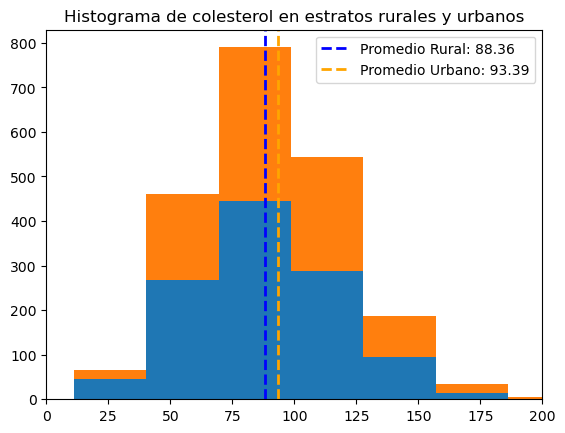

In [58]:
mean_1 = df[df['estrato'] == 1]['valor_COL_LDL'].mean()
mean_2 = df[df['estrato'] == 2]['valor_COL_LDL'].mean()
plt.hist([df[df['estrato'] == 1]['valor_COL_LDL'], df[df['estrato'] == 2]['valor_COL_LDL']], stacked=True)
plt.axvline(mean_1, color='b', linestyle='dashed', linewidth=2, label=f'Promedio Rural: {mean_1:.2f}')
plt.axvline(mean_2, color='orange', linestyle='dashed', linewidth=2, label=f'Promedio Urbano: {mean_2:.2f}')
plt.xlim(0, 200)
plt.legend()
plt.title('Histograma de colesterol en estratos rurales y urbanos')
plt.show()

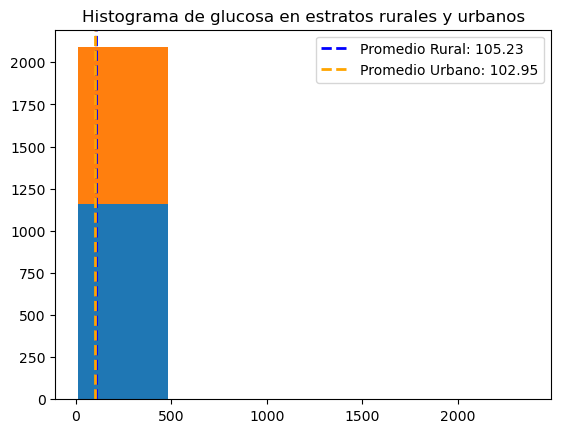

In [65]:
mean_1 = df[df['estrato'] == 1]['valor_GLU_SUERO'].mean()
mean_2 = df[df['estrato'] == 2]['valor_GLU_SUERO'].mean()
plt.hist([df[df['estrato'] == 1]['valor_GLU_SUERO'], df[df['estrato'] == 2]['valor_GLU_SUERO']], stacked=True, bins=5)
plt.axvline(mean_1, color='b', linestyle='dashed', linewidth=2, label=f'Promedio Rural: {mean_1:.2f}')
plt.axvline(mean_2, color='orange', linestyle='dashed', linewidth=2, label=f'Promedio Urbano: {mean_2:.2f}')
plt.legend()
plt.title('Histograma de glucosa en estratos rurales y urbanos')
plt.show()

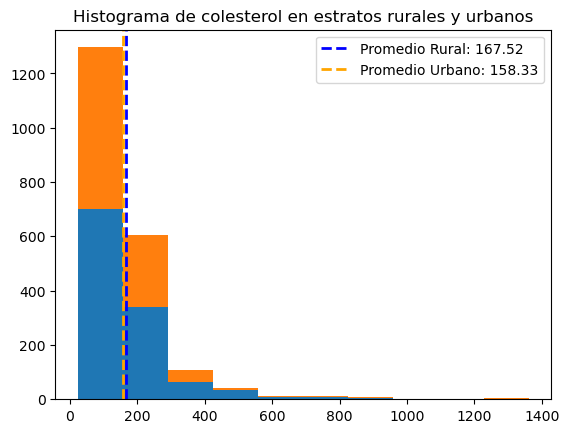

In [66]:
mean_1 = df[df['estrato'] == 1]['valor_TRIG'].mean()
mean_2 = df[df['estrato'] == 2]['valor_TRIG'].mean()
plt.hist([df[df['estrato'] == 1]['valor_TRIG'], df[df['estrato'] == 2]['valor_TRIG']], stacked=True)
plt.axvline(mean_1, color='b', linestyle='dashed', linewidth=2, label=f'Promedio Rural: {mean_1:.2f}')
plt.axvline(mean_2, color='orange', linestyle='dashed', linewidth=2, label=f'Promedio Urbano: {mean_2:.2f}')
plt.legend()
plt.title('Histograma de colesterol en estratos rurales y urbanos')
plt.show()

In [12]:
data_PCA=df[['entidad','valor_COL_LDL','valor_GLU_SUERO','valor_TRIG']]
data_PCA.head()


,entidad,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
0,1,130.0,111.0,131.0
1,1,107.0,106.0,297.0
2,1,76.0,109.0,136.0
3,1,84.0,98.0,121.0
4,1,119.0,253.0,257.0


In [ ]:
data_PCA_used=data_PCA.drop(['entidad'],axis=1)

# Estandarización
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
scaled_X = sc.fit_transform(data_PCA_used)  
scaled_X[:5]   

#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(scaled_X)   # Returns a NumPy array 
X_pca[:5]

PC1 = X_pca[:,0]   # Extract the first column
PC2 = X_pca[:,1]   # Extract the second column

df_PCA = pd.DataFrame({'PC1': PC1, 'PC2': PC2, 'label': data_PCA['entidad']})
df_PCA.head()


,PC1,PC2,label
0,0.673880,-0.319976,1
1,0.993468,-0.503244,1
2,-0.392421,0.305290,1
3,-0.382473,0.106677,1
4,2.054466,1.276469,1


In [17]:
pca.explained_variance_ratio_

array([0.44487549, 0.29904702, 0.25607749])

In [ ]:
for index, component in enumerate(np.round(pca.components_, 2)):
    res = []
    for value, col_name in zip(component, data_PCA_used.columns):
        res.append(f'{value} {col_name}')
    print(f'PC{index+1}: ' + ' + '.join(res))
#PCA1 es el bueno


PC1: 0.61 valor_COL_LDL + 0.49 valor_GLU_SUERO + 0.62 valor_TRIG
PC2: -0.38 valor_COL_LDL + 0.87 valor_GLU_SUERO + -0.31 valor_TRIG
PC3: -0.69 valor_COL_LDL + -0.05 valor_GLU_SUERO + 0.72 valor_TRIG


In [ ]:
# 2. Columnas de biomarcadores
cols = ["valor_COL_LDL", "valor_GLU_SUERO", "valor_TRIG"]

# 3. Agrupar por estado y sacar promedios
df_scores = df.groupby("desc_ent")[cols].mean().reset_index()

# 4. Renombrar columnas para que queden bonitas
df_scores.rename(columns={
    "desc_ent": "Estado",
    "valor_COL_LDL": "Colesterol_LDL_Promedio",
    "valor_GLU_SUERO": "Glucosa_Promedio",
    "valor_TRIG": "Trigliceridos_Promedio"
}, inplace=True)

# 5. Definir las cargas de PC1 que obtuviste
w_TG  = 0.62
w_LDL = 0.61
w_GLU = 0.49

# 6. Aplicar la fórmula de PC1 sobre los promedios (índice compuesto)
df_scores["Score_Salud"] = (
    w_LDL * df_scores["Colesterol_LDL_Promedio"] +
    w_GLU * df_scores["Glucosa_Promedio"] +
    w_TG  * df_scores["Trigliceridos_Promedio"]
)

# 7. Crear un nuevo dataset solo con las columnas finales que quieres
df_nuevo = df_scores[[
    "Estado",
    "Colesterol_LDL_Promedio",
    "Glucosa_Promedio",
    "Trigliceridos_Promedio",
    "Score_Salud"
]]



    Estado  Colesterol_LDL_Promedio  Glucosa_Promedio  Trigliceridos_Promedio  \
4  CHIAPAS                75.852459        102.327869              156.868852   

   Score_Salud  
4   193.669344  


In [26]:
df_nuevo.head()

,Estado,Colesterol_LDL_Promedio,Glucosa_Promedio,Trigliceridos_Promedio,Score_Salud
0,AGUASCALIENTES,104.214286,108.595238,163.142857,217.930952
1,BAJA CALIFORNIA,87.250000,97.568182,153.704545,196.327727
2,BAJA CALIFORNIA SUR,81.781250,104.437500,131.812500,182.784687
3,CAMPECHE,73.983333,94.333333,163.983333,193.022833
4,CHIAPAS,75.852459,102.327869,156.868852,193.669344


In [37]:
import numpy as np

# Cargas de PC1 (LDL, glucosa, triglicéridos)
cargas = np.array([0.61, 0.49, 0.62])

# Valores máximos tolerables promedio para test
LDL = 99
GLU = 100
TG  = 149

score = cargas[0]*LDL + cargas[1]*GLU + cargas[2]*TG
print("Score test:", round(score, 2))


Score test: 201.77


In [47]:
# 2. Columnas de biomarcadores
cols = ["valor_COL_LDL", "valor_GLU_SUERO", "valor_TRIG"]

# 3. Agrupar por estado y sacar promedios
df_scores = df.groupby("desc_ent")[cols].mean().reset_index()

# 4. Renombrar
df_scores.rename(columns={
    "desc_ent": "Estado",
    "valor_COL_LDL": "Colesterol_LDL_Promedio",
    "valor_GLU_SUERO": "Glucosa_Promedio",
    "valor_TRIG": "Trigliceridos_Promedio"
}, inplace=True)

# 5. Cargas de PC1
w_TG  = 0.62
w_LDL = 0.61
w_GLU = 0.49

# 6. Score en crudo para todos los estados
df_scores["Score_Salud"] = (
    w_LDL * df_scores["Colesterol_LDL_Promedio"] +
    w_GLU * df_scores["Glucosa_Promedio"] +
    w_TG  * df_scores["Trigliceridos_Promedio"]
)

# B) Calcular el score máximo OMS (crudo)
# Usando los valores que definiste como tolerables en el test:
LDL_OMS = 99
GLU_OMS = 100
TG_OMS  = 149

score_OMS = 0.61*LDL_OMS + 0.49*GLU_OMS + 0.62*TG_OMS

# C) Nueva columna: diferencias contra el score OMS
df_scores["Diferencia_Salud"] = df_scores["Score_Salud"] - score_OMS

# 7. Dataset final
df_nuevo = df_scores[[
    "Estado",
    "Colesterol_LDL_Promedio",
    "Glucosa_Promedio",
    "Trigliceridos_Promedio",
    "Score_Salud",
    "Diferencia_Salud"
]]

# 01 al 16 (filas 0–15)
for i in range(0, 16):
    row = df_nuevo.iloc[i]
    print(f"{i+1:02d} - {row['Estado']}: {row['Diferencia_Salud']:.2f}")
    

01 - AGUASCALIENTES: 16.16
02 - BAJA CALIFORNIA: -5.44
03 - BAJA CALIFORNIA SUR: -18.99
04 - CAMPECHE: -8.75
05 - CHIAPAS: -8.10
06 - CHIHUAHUA: 1.13
07 - CIUDAD DE MÉXICO: 18.03
08 - COAHUILA DE ZARAGOZA: 25.86
09 - COLIMA: -10.19
10 - DURANGO: 21.43
11 - GUANAJUATO: 10.54
12 - GUERRERO: -1.99
13 - HIDALGO: -0.04
14 - JALISCO: -5.90
15 - MICHOACÁN DE OCAMPO: 18.72
16 - MORELOS: 9.45


In [46]:
df_nuevo.head()

,Estado,Colesterol_LDL_Promedio,Glucosa_Promedio,Trigliceridos_Promedio,Score_Salud,Diferencia_Salud
0,AGUASCALIENTES,104.214286,108.595238,163.142857,217.930952,16.160952
1,BAJA CALIFORNIA,87.250000,97.568182,153.704545,196.327727,-5.442273
2,BAJA CALIFORNIA SUR,81.781250,104.437500,131.812500,182.784687,-18.985312
3,CAMPECHE,73.983333,94.333333,163.983333,193.022833,-8.747167
4,CHIAPAS,75.852459,102.327869,156.868852,193.669344,-8.100656


In [52]:
# 17 al 31 (filas 16–30)
for i in range(16, 32):
    row = df_nuevo.iloc[i]
    print(f"{i+1:02d} - {row['Estado']}: {row['Diferencia_Salud']:.2f}")

17 - MÉXICO: 18.52
18 - NAYARIT: -0.03
19 - NUEVO LEÓN: 1.74
20 - OAXACA: -0.09
21 - PUEBLA: 35.92
22 - QUERÉTARO: -13.78
23 - QUINTANA ROO: 16.72
24 - SAN LUIS POTOSÍ: 29.58
25 - SINALOA: -20.98
26 - SONORA: -23.58
27 - TABASCO: 22.20
28 - TAMAULIPAS: -30.33
29 - TLAXCALA: 47.82
30 - VERACRUZ DE IGNACIO DE LA LLAVE: 12.75
31 - YUCATÁN: 16.56
32 - ZACATECAS: -5.73
